# 01 - Statistical Learning Theory and the Bias-Variance Decomposition

**Advanced Machine Learning** | Haydar Kilic

Supervised learning looks for a function $f:\mathcal{X}\to\mathcal{Y}$ with small
**risk**

$$R(f) = \mathbb{E}_{(x,y)\sim P}\bigl[\ell(y, f(x))\bigr].$$

$P$ is unknown, so we minimise the **empirical risk** on a sample instead,

$$\hat R_n(f) = \frac1n \sum_{i=1}^n \ell(y_i, f(x_i)),$$

and the entire theory of the field is about controlling the gap
$R(f) - \hat R_n(f)$. This notebook studies that gap experimentally: first as
the classical bias-variance trade-off, then through learning curves, and
finally through the selection bias that appears when the same data is used to
both tune and evaluate a model.

In [1]:
# =======================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =======================================================================
from __future__ import annotations

import numpy as np
from itertools import combinations_with_replacement

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_polynomial(n_samples=100, degree=3, noise=0.3, random_state=None):
    """1-D regression with a fixed polynomial target of the given degree."""
    rng = _rng(random_state)
    coefs = np.array([0.5, -1.0, 0.8, -0.3, 0.05])[: degree + 1]
    X = rng.uniform(-2.0, 2.0, size=(n_samples, 1))
    powers = X[:, 0:1] ** np.arange(len(coefs))
    y = powers @ coefs + noise * rng.standard_normal(n_samples)
    return X, y

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean((y_true - y_pred) ** 2))

# --- preprocessing -------------------------------------------------

class StandardScaler:
    """Zero mean / unit variance scaling."""

    def __init__(self, with_mean=True, with_std=True):
        self.with_mean = with_mean
        self.with_std = with_std

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.mean_ = X.mean(axis=0) if self.with_mean else np.zeros(X.shape[1])
        scale = X.std(axis=0) if self.with_std else np.ones(X.shape[1])
        self.scale_ = np.where(scale < 1e-12, 1.0, scale)
        return self

    def transform(self, X):
        return (np.asarray(X, float) - self.mean_) / self.scale_

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return np.asarray(X, float) * self.scale_ + self.mean_

class PolynomialFeatures:
    """Monomials up to ``degree`` (interactions included, bias excluded)."""

    def __init__(self, degree=2, include_bias=False):
        self.degree = int(degree)
        self.include_bias = include_bias

    def fit(self, X, y=None):
        n_features = np.asarray(X).shape[1]
        combos = []
        if self.include_bias:
            combos.append(())
        for d in range(1, self.degree + 1):
            combos.extend(combinations_with_replacement(range(n_features), d))
        self.combinations_ = combos
        return self

    def transform(self, X):
        X = np.asarray(X, float)
        cols = []
        for combo in self.combinations_:
            if not combo:
                cols.append(np.ones(len(X)))
            else:
                col = np.ones(len(X))
                for j in combo:
                    col = col * X[:, j]
                cols.append(col)
        return np.stack(cols, axis=1)

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

class Pipeline:
    """Chain of transformers followed by a final estimator.

    ``Pipeline([("poly", PolynomialFeatures(3)), ("model", RidgeRegression())])``
    """

    def __init__(self, steps):
        self.steps = list(steps)

    @property
    def named_steps(self):
        return dict(self.steps)

    def fit(self, X, y=None):
        Xt = np.asarray(X, float)
        for _, step in self.steps[:-1]:
            Xt = step.fit_transform(Xt, y)
        self.steps[-1][1].fit(Xt, y)
        return self

    def _transform(self, X):
        Xt = np.asarray(X, float)
        for _, step in self.steps[:-1]:
            Xt = step.transform(Xt)
        return Xt

    def predict(self, X):
        return self.steps[-1][1].predict(self._transform(X))

    def predict_proba(self, X):
        return self.steps[-1][1].predict_proba(self._transform(X))

# --- linear --------------------------------------------------------

class _CenteredLinearModel:
    """Shared centring logic: fit on centred data, recover the intercept after."""

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = 0.0

    def _center(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if self.fit_intercept:
            self._x_mean = X.mean(axis=0)
            self._y_mean = y.mean()
            return X - self._x_mean, y - self._y_mean
        self._x_mean = np.zeros(X.shape[1])
        self._y_mean = 0.0
        return X, y

    def _set_intercept(self):
        self.intercept_ = float(self._y_mean - self._x_mean @ self.coef_)

    def predict(self, X):
        return np.asarray(X, float) @ self.coef_ + self.intercept_

class RidgeRegression(_CenteredLinearModel):
    r"""Ridge regression.

    Minimises :math:`\|y - Xw\|_2^2 + \alpha \|w\|_2^2`.  The SVD
    :math:`X = U D V^\top` gives the shrinkage form

    .. math:: \hat w = V \operatorname{diag}\!\left(\frac{d_j}{d_j^2+\alpha}\right) U^\top y,

    which also exposes the effective degrees of freedom
    :math:`\mathrm{df}(\alpha) = \sum_j d_j^2 / (d_j^2 + \alpha)`.
    """

    def __init__(self, alpha=1.0, fit_intercept=True):
        super().__init__(fit_intercept)
        self.alpha = float(alpha)

    def fit(self, X, y):
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        shrink = d / (d**2 + self.alpha)
        self.coef_ = Vt.T @ (shrink * (U.T @ yc))
        self.singular_values_ = d
        self.effective_dof_ = float(np.sum(d**2 / (d**2 + self.alpha)))
        self._set_intercept()
        return self

    def path(self, X, y, alphas):
        """Coefficient path over a grid of ``alphas`` (one row per alpha)."""
        Xc, yc = self._center(X, y)
        U, d, Vt = np.linalg.svd(Xc, full_matrices=False)
        Uty = U.T @ yc
        return np.stack([Vt.T @ ((d / (d**2 + a)) * Uty) for a in alphas])

# --- model_selection -----------------------------------------------

class KFold:
    """K-fold index generator with optional shuffling."""

    def __init__(self, n_splits=5, shuffle=True, random_state=None):
        if n_splits < 2:
            raise ValueError("n_splits must be at least 2.")
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        n = len(X)
        idx = np.arange(n)
        if self.shuffle:
            np.random.default_rng(self.random_state).shuffle(idx)
        fold_sizes = np.full(self.n_splits, n // self.n_splits, dtype=int)
        fold_sizes[: n % self.n_splits] += 1
        start = 0
        for size in fold_sizes:
            val_idx = idx[start : start + size]
            train_idx = np.concatenate([idx[:start], idx[start + size :]])
            yield train_idx, val_idx
            start += size

def cross_val_score(estimator_factory, X, y, scorer=mse, cv=5, random_state=None):
    """Return the per-fold scores of ``estimator_factory`` on ``(X, y)``."""
    X, y = np.asarray(X), np.asarray(y)
    splitter = cv if isinstance(cv, KFold) else KFold(cv, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, val_idx in splitter.split(X):
        model = estimator_factory()
        model.fit(X[train_idx], y[train_idx])
        scores.append(scorer(y[val_idx], model.predict(X[val_idx])))
    return np.asarray(scores, dtype=float)

def _product(*iterables):
    """Small stand-in for ``itertools.product`` (kept explicit for readability)."""
    result = [[]]
    for pool in iterables:
        result = [prefix + [item] for prefix in result for item in pool]
    return [tuple(r) for r in result]

def grid_search_cv(build, param_grid, X, y, scorer=mse, cv=5, greater_is_better=False,
                   random_state=None):
    """Exhaustive grid search.

    ``build`` maps a parameter dict to an estimator factory, e.g.::

        build = lambda p: (lambda: RidgeRegression(**p))

    Returns ``(best_params, best_score, all_results)``.
    """
    keys = list(param_grid)
    results = []
    for combo in _product(*(param_grid[k] for k in keys)):
        params = dict(zip(keys, combo))
        scores = cross_val_score(build(params), X, y, scorer=scorer, cv=cv,
                                 random_state=random_state)
        results.append((params, float(scores.mean()), float(scores.std())))
    key = (lambda r: -r[1]) if greater_is_better else (lambda r: r[1])
    best = min(results, key=key)
    return best[0], best[1], results

def nested_cv_score(build, param_grid, X, y, scorer=mse, outer_cv=5, inner_cv=4,
                    greater_is_better=False, random_state=None):
    """Nested CV: an unbiased estimate of the *tuning procedure's* performance."""
    X, y = np.asarray(X), np.asarray(y)
    outer = KFold(outer_cv, shuffle=True, random_state=random_state)
    scores, chosen = [], []
    for train_idx, test_idx in outer.split(X):
        best_params, _, _ = grid_search_cv(
            build, param_grid, X[train_idx], y[train_idx], scorer=scorer, cv=inner_cv,
            greater_is_better=greater_is_better, random_state=random_state,
        )
        model = build(best_params)()
        model.fit(X[train_idx], y[train_idx])
        scores.append(scorer(y[test_idx], model.predict(X[test_idx])))
        chosen.append(best_params)
    return np.asarray(scores, dtype=float), chosen

def bias_variance_decomposition(estimator_factory, X_train, y_train, X_test, y_test,
                                n_rounds=50, random_state=None):
    r"""Bootstrap estimate of the squared-error decomposition.

    .. math::
        \mathbb{E}\bigl[(y - \hat f(x))^2\bigr]
        = \underbrace{(\bar f(x) - f(x))^2}_{\text{bias}^2}
        + \underbrace{\mathbb{E}[(\hat f(x) - \bar f(x))^2]}_{\text{variance}}
        + \sigma^2 .

    ``y_test`` stands in for :math:`f(x)`, so the reported bias term absorbs the
    irreducible noise of the test targets -- exactly as in Kohavi & Wolpert's
    empirical version.  Returns ``(expected_loss, bias2, variance)``.
    """
    rng = np.random.default_rng(random_state)
    X_train, y_train = np.asarray(X_train), np.asarray(y_train)
    X_test, y_test = np.asarray(X_test), np.asarray(y_test, float)

    n = len(X_train)
    preds = np.empty((n_rounds, len(X_test)))
    for r in range(n_rounds):
        boot = rng.integers(0, n, size=n)
        model = estimator_factory()
        model.fit(X_train[boot], y_train[boot])
        preds[r] = model.predict(X_test)

    mean_pred = preds.mean(axis=0)
    bias2 = float(np.mean((mean_pred - y_test) ** 2))
    variance = float(np.mean(preds.var(axis=0)))
    expected_loss = float(np.mean((preds - y_test[None, :]) ** 2))
    return expected_loss, bias2, variance

def learning_curve(estimator_factory, X_train, y_train, X_test, y_test,
                   train_sizes=(0.1, 0.25, 0.5, 0.75, 1.0), scorer=mse, n_repeats=5,
                   random_state=None):
    """Train/test score as a function of the training-set size."""
    rng = np.random.default_rng(random_state)
    X_train, y_train = np.asarray(X_train), np.asarray(y_train)
    n = len(X_train)
    sizes, train_scores, test_scores = [], [], []
    for frac in train_sizes:
        m = max(2, int(round(frac * n)))
        tr, te = [], []
        for _ in range(n_repeats):
            idx = rng.choice(n, size=m, replace=False)
            model = estimator_factory()
            model.fit(X_train[idx], y_train[idx])
            tr.append(scorer(y_train[idx], model.predict(X_train[idx])))
            te.append(scorer(y_test, model.predict(X_test)))
        sizes.append(m)
        train_scores.append(np.mean(tr))
        test_scores.append(np.mean(te))
    return np.asarray(sizes), np.asarray(train_scores), np.asarray(test_scores)

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

In [2]:
plt = set_style()
rng = np.random.default_rng(0)

X, y = make_polynomial(n_samples=160, degree=3, noise=0.4, random_state=17)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=0)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (104, 1), test: (56, 1)


## 1. Capacity and the two errors

We control capacity with the degree of a polynomial basis. Note that the
*training* error can only fall as the degree grows -- the hypothesis classes are
nested, $\mathcal{F}_1 \subset \mathcal{F}_2 \subset \dots$ -- while the test
error eventually turns around. That turning point is the whole problem.

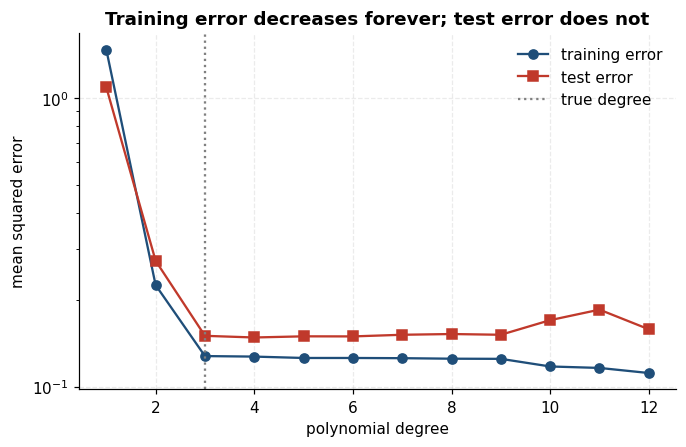

degree with the lowest test error: 4


In [3]:
def polynomial_model(degree, alpha=1e-8):
    """Fresh (unfitted) pipeline: monomials -> standardisation -> ridge."""
    return lambda: Pipeline([
        ("poly", PolynomialFeatures(degree)),
        ("scale", StandardScaler()),
        ("model", RidgeRegression(alpha=alpha)),
    ])


degrees = np.arange(1, 13)
train_err, test_err = [], []
for d in degrees:
    model = polynomial_model(d)()
    model.fit(X_train, y_train)
    train_err.append(mse(y_train, model.predict(X_train)))
    test_err.append(mse(y_test, model.predict(X_test)))

fig, ax = plt.subplots()
ax.plot(degrees, train_err, "o-", label="training error")
ax.plot(degrees, test_err, "s-", label="test error")
ax.axvline(3, color="grey", ls=":", label="true degree")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error")
ax.set_title("Training error decreases forever; test error does not")
ax.legend()
plt.show()

best_degree = int(degrees[int(np.argmin(test_err))])
print(f"degree with the lowest test error: {best_degree}")

## 2. Where the test error comes from

For squared loss and a fixed input $x$, with $y = f(x) + \varepsilon$ and
$\mathbb{E}[\varepsilon]=0$, $\operatorname{Var}(\varepsilon)=\sigma^2$:

$$\mathbb{E}_{\mathcal{D}}\bigl[(y - \hat f_{\mathcal{D}}(x))^2\bigr]
= \underbrace{\bigl(\bar f(x) - f(x)\bigr)^2}_{\text{bias}^2}
+ \underbrace{\mathbb{E}_{\mathcal{D}}\bigl[(\hat f_{\mathcal{D}}(x) - \bar f(x))^2\bigr]}_{\text{variance}}
+ \underbrace{\sigma^2}_{\text{irreducible}},$$

where $\bar f(x) = \mathbb{E}_{\mathcal{D}}[\hat f_{\mathcal{D}}(x)]$ averages over
training sets. We approximate the expectation over $\mathcal{D}$ by bootstrap
resampling; because the reference is the *noisy* test target, the estimated
bias term absorbs $\sigma^2$ (the Kohavi-Wolpert convention).

degree  1 | loss    1.149 = bias^2    1.098 + variance    0.051
degree  2 | loss    0.287 = bias^2    0.278 + variance    0.009
degree  3 | loss    0.156 = bias^2    0.151 + variance    0.005
degree  4 | loss    0.156 = bias^2    0.149 + variance    0.007
degree  6 | loss    0.166 = bias^2    0.149 + variance    0.017
degree  8 | loss    0.284 = bias^2    0.182 + variance    0.101
degree 10 | loss    0.702 = bias^2    0.199 + variance    0.503


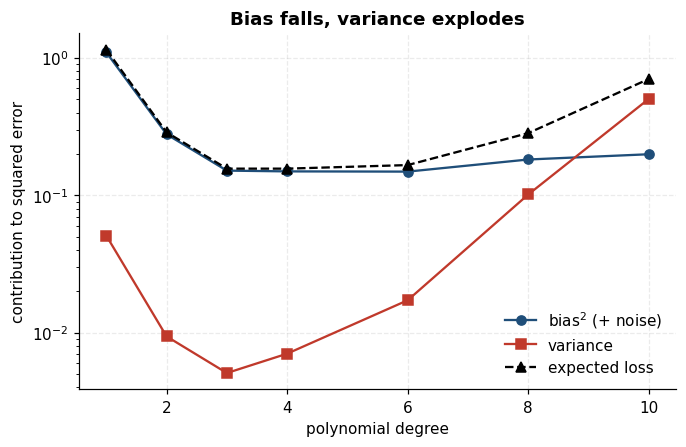

In [4]:
rows = []
for d in [1, 2, 3, 4, 6, 8, 10]:
    loss, bias2, var = bias_variance_decomposition(
        polynomial_model(d), X_train, y_train, X_test, y_test,
        n_rounds=80, random_state=1,
    )
    rows.append((d, loss, bias2, var))
    print(f"degree {d:2d} | loss {loss:8.3f} = bias^2 {bias2:8.3f} + variance {var:8.3f}")

rows = np.array(rows)
fig, ax = plt.subplots()
ax.plot(rows[:, 0], rows[:, 2], "o-", label="bias$^2$ (+ noise)")
ax.plot(rows[:, 0], rows[:, 3], "s-", label="variance")
ax.plot(rows[:, 0], rows[:, 1], "k^--", label="expected loss")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("contribution to squared error")
ax.set_title("Bias falls, variance explodes")
ax.legend()
plt.show()

The two components move in opposite directions and their sum is U-shaped. The
code also verifies the identity numerically: `loss` equals `bias2 + var` to
machine precision, because that is exactly how the bootstrap estimator is
constructed.

### Regularisation moves along the same curve

We do not have to change the degree to change the effective capacity. Ridge
keeps degree 10 but shrinks the coefficients, and the *effective degrees of
freedom* $\mathrm{df}(\alpha)=\sum_j d_j^2/(d_j^2+\alpha)$ (with $d_j$ the
singular values of $X$) makes the resulting capacity explicit.

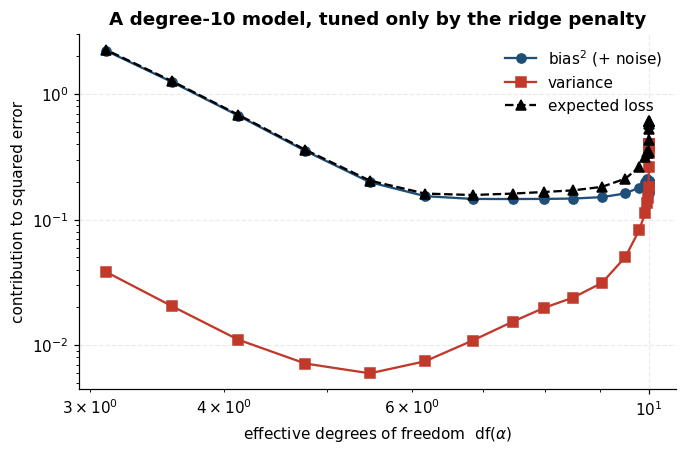

best alpha by expected loss: 1.78  (df = 6.84)


In [5]:
alphas = np.logspace(-8, 3, 25)
dofs, losses, biases, variances = [], [], [], []
Z = PolynomialFeatures(10).fit_transform(StandardScaler().fit_transform(X_train))
for a in alphas:
    dofs.append(RidgeRegression(alpha=a).fit(Z, y_train).effective_dof_)
    loss, bias2, var = bias_variance_decomposition(
        polynomial_model(10, alpha=a), X_train, y_train, X_test, y_test,
        n_rounds=40, random_state=1,
    )
    losses.append(loss)
    biases.append(bias2)
    variances.append(var)

fig, ax = plt.subplots()
ax.plot(dofs, biases, "o-", label="bias$^2$ (+ noise)")
ax.plot(dofs, variances, "s-", label="variance")
ax.plot(dofs, losses, "k^--", label="expected loss")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"effective degrees of freedom  df($\alpha$)")
ax.set_ylabel("contribution to squared error")
ax.set_title("A degree-10 model, tuned only by the ridge penalty")
ax.legend()
plt.show()

print(f"best alpha by expected loss: {alphas[int(np.argmin(losses))]:.3g}"
      f"  (df = {dofs[int(np.argmin(losses))]:.2f})")

## 3. Learning curves: how much data would help?

Bias and variance also answer a practical question. A high-variance model
improves quickly with more data (the two curves converge); a high-bias model
plateaus at a level no amount of data can fix.

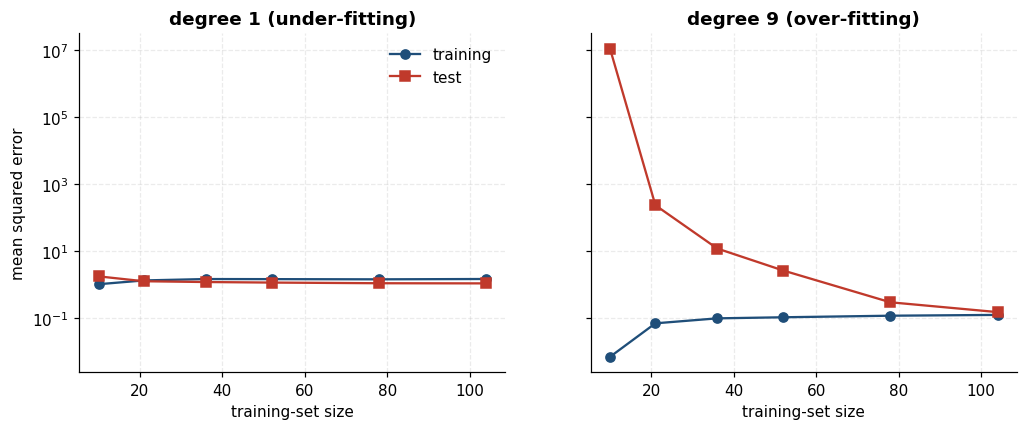

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, d in zip(axes, [1, 9]):
    sizes, tr, te = learning_curve(
        polynomial_model(d), X_train, y_train, X_test, y_test,
        train_sizes=(0.1, 0.2, 0.35, 0.5, 0.75, 1.0), n_repeats=25, random_state=2,
    )
    ax.plot(sizes, tr, "o-", label="training")
    ax.plot(sizes, te, "s-", label="test")
    ax.set_title(f"degree {d} ({'under' if d == 1 else 'over'}-fitting)")
    ax.set_xlabel("training-set size")
    ax.set_yscale("log")
axes[0].set_ylabel("mean squared error")
axes[0].legend()
plt.show()

## 4. Selecting a model without fooling yourself

If the same cross-validation score both *chooses* the hyper-parameter and
*reports* the performance, that score is optimistically biased: it is the
minimum over a grid of noisy estimates. Nested cross-validation separates the
two roles -- an inner loop tunes, an outer loop evaluates the tuning procedure
as a whole.

In [7]:
grid = {"degree": [1, 2, 3, 4, 6, 8, 10]}
build = lambda p: polynomial_model(p["degree"])

best_params, best_cv_score, results = grid_search_cv(
    build, grid, X_train, y_train, cv=5, random_state=3,
)
outer_scores, chosen = nested_cv_score(
    build, grid, X_train, y_train, outer_cv=5, inner_cv=4, random_state=3,
)

print(f"selected degree              : {best_params['degree']}")
print(f"optimistic (inner) CV error  : {best_cv_score:.4f}")
print(f"nested CV error              : {outer_scores.mean():.4f} "
      f"+/- {outer_scores.std():.4f}")
print(f"degrees chosen in outer folds: {[c['degree'] for c in chosen]}")

final_model = polynomial_model(best_params["degree"])().fit(X_train, y_train)
print(f"held-out test error          : {mse(y_test, final_model.predict(X_test)):.4f}")

selected degree              : 6
optimistic (inner) CV error  : 0.1381
nested CV error              : 0.1382 +/- 0.0163
degrees chosen in outer folds: [3, 3, 3, 3, 3]
held-out test error          : 0.1494


Two things are worth noticing. The gap between the two estimates is tiny here --
the signal is strong and the grid is small, so there is little room to get
lucky. But the outer folds unanimously choose degree 3 while the full-data grid
search reports degree 6: the *selected value itself* is driven by noise, even
when the resulting error barely differs.

The bias becomes unmistakable when there is nothing to find. Below the target is
pure noise, so no model can beat predicting the mean -- whose error is simply the
variance of $y$.

In [8]:
noise_rng = np.random.default_rng(5)
X_noise = noise_rng.standard_normal((80, 6))
y_noise = noise_rng.standard_normal(80)          # no relationship whatsoever

noise_grid = {"degree": [1, 2, 3], "alpha": [1e-6, 1e-3, 1e-1, 1.0, 10.0, 100.0]}
noise_build = lambda p: polynomial_model(p["degree"], alpha=p["alpha"])

best_noise, inner_noise, all_noise = grid_search_cv(
    noise_build, noise_grid, X_noise, y_noise, cv=5, random_state=0,
)
nested_noise, _ = nested_cv_score(
    noise_build, noise_grid, X_noise, y_noise, outer_cv=5, inner_cv=4, random_state=0,
)

print(f"candidates in the grid            : {len(all_noise)}")
print(f"baseline (predict the mean)       : {np.var(y_noise):.4f}")
print(f"best inner CV score over the grid : {inner_noise:.4f}   <- reported as 'our model'")
print(f"nested CV score                   : {nested_noise.mean():.4f} "
      f"+/- {nested_noise.std():.4f}")

candidates in the grid            : 18
baseline (predict the mean)       : 1.1394
best inner CV score over the grid : 1.2181   <- reported as 'our model'
nested CV score                   : 1.3439 +/- 0.4367


The inner score looks respectable, close to the baseline; the nested score is
clearly worse than predicting the mean -- which is the truth, because there is no
signal at all. The distance between those two numbers is exactly how much a grid
search flatters itself, and it grows with the size of the grid.

## 5. What to take away

1. Empirical risk minimisation alone does not control the true risk; capacity
   must be constrained, whether by the hypothesis class or by a penalty.
2. The expected squared error splits cleanly into bias, variance and noise, and
   every regularisation knob trades the first two against each other.
3. Effective degrees of freedom give a continuous measure of capacity, which is
   more useful than a discrete model index.
4. Learning curves say whether to buy more data or a better model.
5. Any hyper-parameter search must be nested inside the evaluation loop, or the
   reported number is an optimistic one.

**Next:** notebook 02 turns the ridge penalty into an $\ell_1$ penalty and asks
what changes when the objective is no longer differentiable.